<center><h1>Разведочный анализ данных</h1></center>

<h2>0. Импорт</h2>

In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
import pandas as pd
import numpy as np

from EDA import (nunique_val, 
                picture_rooms_price,
                count_rooms, 
                picture_area_price, 
                picture_metro_price, 
                picture_district_price,
                picture_district_price_ascending,
                metro_transport_value_c,
                walk_transport_metro_different_price,
                walk_transport_between_thousand,
                test_of_normal,
                test_mannwhitney,
                distribution_price,
                value_count_seller_type,
                picture_seller_type_price)

<h5>0.1 Чтение и изучение файла</h5>

In [24]:
data = pd.read_csv('/Users/muzaladinovdzamalladinruslanovic/Desktop/PROJECT CIAN/data/full data/cian_preprocessing.csv', index_col=0)
data.head()

,rooms,area,floor,floors_total,metro,metro_minutes,metro_transport,district,seller_type,price_rub
0,4.0,86.0,3,18,Корниловская,18.0,walk,Мосрентген,agency,26285040.0
1,1.0,33.4,2,9,Кокошкино,6.0,walk,Кокошкино,specialist,11000000.0
2,1.0,33.1,1,5,Щёлковская,7.0,walk,Северное Измайлово,specialist,12500000.0
3,1.0,41.3,25,27,Тушинская,8.0,transport,Покровское-Стрешнево,specialist,17500000.0
4,0.0,31.6,32,47,Печатники,13.0,walk,Печатники,agency,19842057.0


<h2>1. Количество уникальных значений в столбцах - metro, district, seller_type, metro_transport</h2>

In [25]:
nunique_val(data, 'metro', 'metro_transport', 'district', 'seller_type')

Количество уникальных значений в столбце metro - 326
Количество уникальных значений в столбце metro_transport - 2
Количество уникальных значений в столбце district - 162
Количество уникальных значений в столбце seller_type - 5


* проведем зависимости цен от каждого признака, и сделаем выводы, от чего зависит цена

<center><h2>2. Зависимости цен от признаков</h2></center>

<h2>2.1 Зависимость цены от количества комнат</h2>

Общее количество количество квартир по числу комнат


rooms,0.0,1.0,2.0,3.0,4.0,5.0,6.0
count,2958,5892,6492,6120,2992,959,447


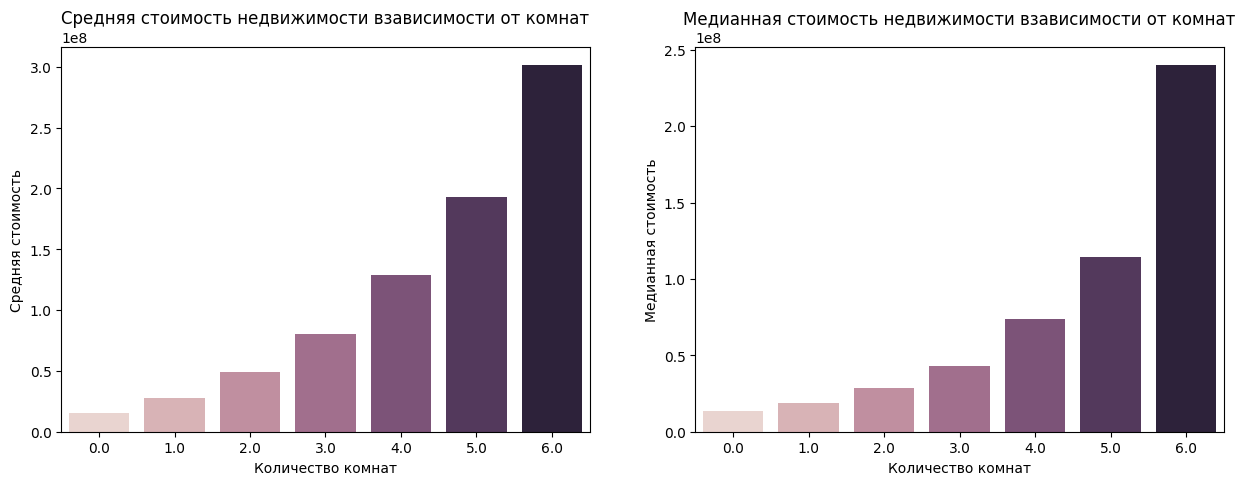

In [26]:
count_rooms(data)
picture_rooms_price(data)

* Ожидаемый результат, все как и должно быть. Цена квартиры растет взависимости от числа комнат.

<h2>2.2 Зависимость цены от площади</h2>

Количество комнат в диапозонах:


area_bin,"[0.0, 50.0)","[50.0, 100.0)","[100.0, 150.0)","[150.0, 200.0)","[200.0, 250.0)","[250.0, 300.0)","[300.0, 350.0)","[350.0, 400.0)","[400.0, 1041.0)"
rooms,9500,10511,3375,1329,570,255,121,66,133


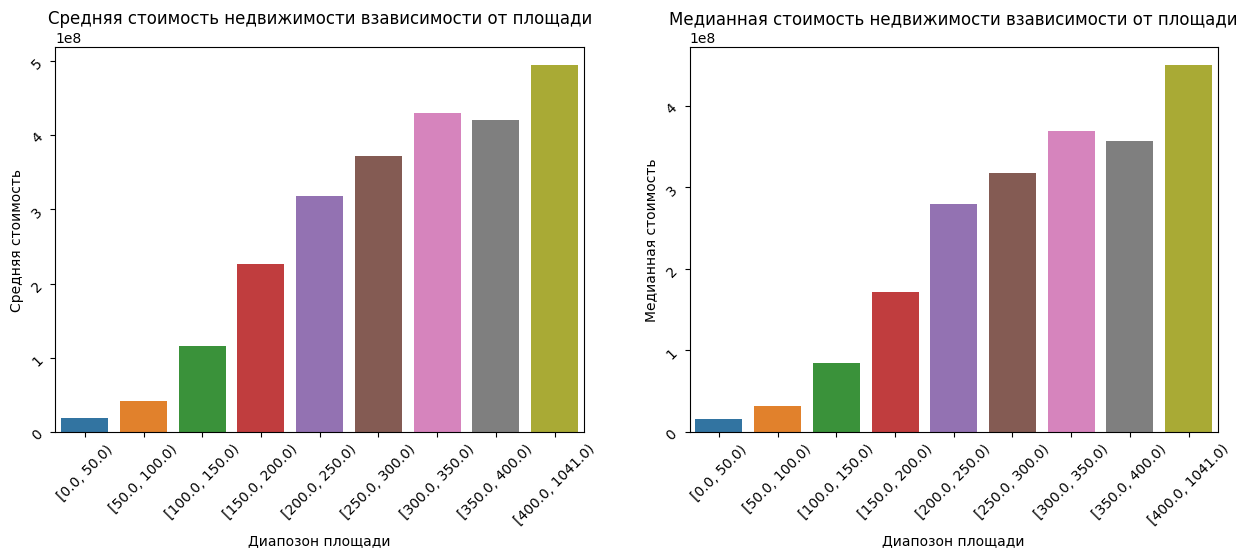

In [27]:
picture_area_price(data)

* самые рентабельные на рынке, это квартиры имеющие небольшую площадь (не более 150 метров). Наибольший спрос имеют квартиры имеющие площадь не более 100 квадратных метров. Цена распределены логично, но можно наблюдать взрывной рост после 150 квадратных метров, а также и после 200. Наименьшую цену имеют квартиры до 50 квадратных метров.

<h2>2.3 Зависимость цены от станции метро</h2>

* станции метро распределены хорошо. В качестве анализа мы возьмем 15 самых популярных.

metro,Аминьевская,Белорусская,Бунинская аллея,Давыдково,ЗИЛ,Москва-Сити,Октябрьское поле,Ольховая,Павелецкая,Потапово,Рассказовка,Терехово,Филатов Луг,Фили,Шелепиха
mean,"49,257,166","106,931,326","14,891,721","45,128,548","36,043,284","123,904,175","46,989,597","15,248,151","105,557,213","18,059,065","19,465,685","86,845,707","15,586,024","69,091,842","43,803,921"
median,"33,095,245","70,900,000","12,750,000","33,203,058","28,900,000","91,270,000","34,903,646","13,354,450","67,076,200","15,345,000","19,400,275","65,000,000","14,852,960","55,270,258","41,328,490"


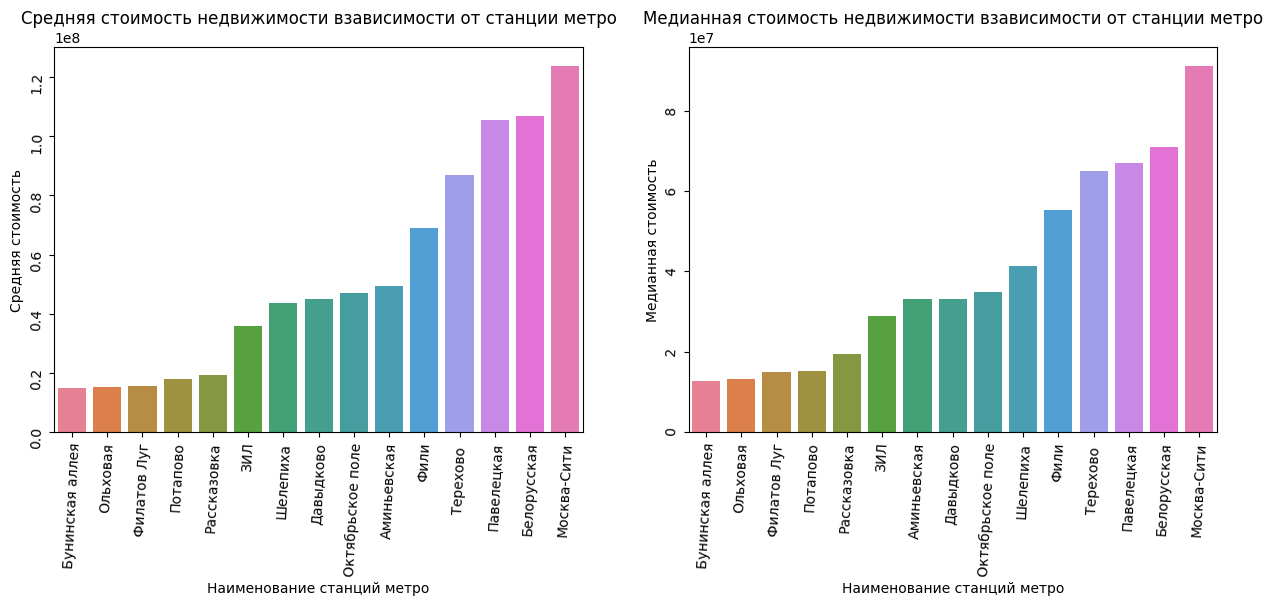

In [28]:
picture_metro_price(data)

* изучив графики выше можно увидеть, что цена мгновенно возрастает у метро ЗИЛ и у далее идущих. Просмотрев карты, я нашел интересную зависимость, если объект недвижимости (по ближайшему метро) находится за МКАДом, то цена сразу же падает, стоит это учесть в будущем, и добавить признак в выборку. Так же стоит заметить, что есть различия в медианной и средней цене между самыми дорогими объектами недвижимости. Значит рядом с этими станциями продается недвижимость, которая сильно ломает среднюю цену. Но также есть где среднее и медиана примерно одинаковы. Это значит, что это обычный спальный район, с обычными квартирами.

<h2>2.4 Зависимость цены от района</h2>

district,Басманный,Даниловский,Дорогомилово,Замоскворечье,Можайский,Московский,Очаково-Матвеевское,Покровское-Стрешнево,Пресненский,Раменки,Сосенское,Тверской,Хамовники,Хорошево-Мневники,Хорошевский
mean,"80,463,169","60,760,240","130,542,626","160,657,875","34,612,123","17,533,078","40,842,040","45,587,920","143,373,871","95,700,927","17,701,670","236,214,094","283,030,626","64,450,517","70,676,566"
median,"52,395,000","41,039,440","93,378,750","93,600,000","28,000,000","16,712,130","25,731,090","30,578,165","99,930,000","59,500,000","15,484,474","143,000,000","244,660,000","45,866,450","49,047,250"


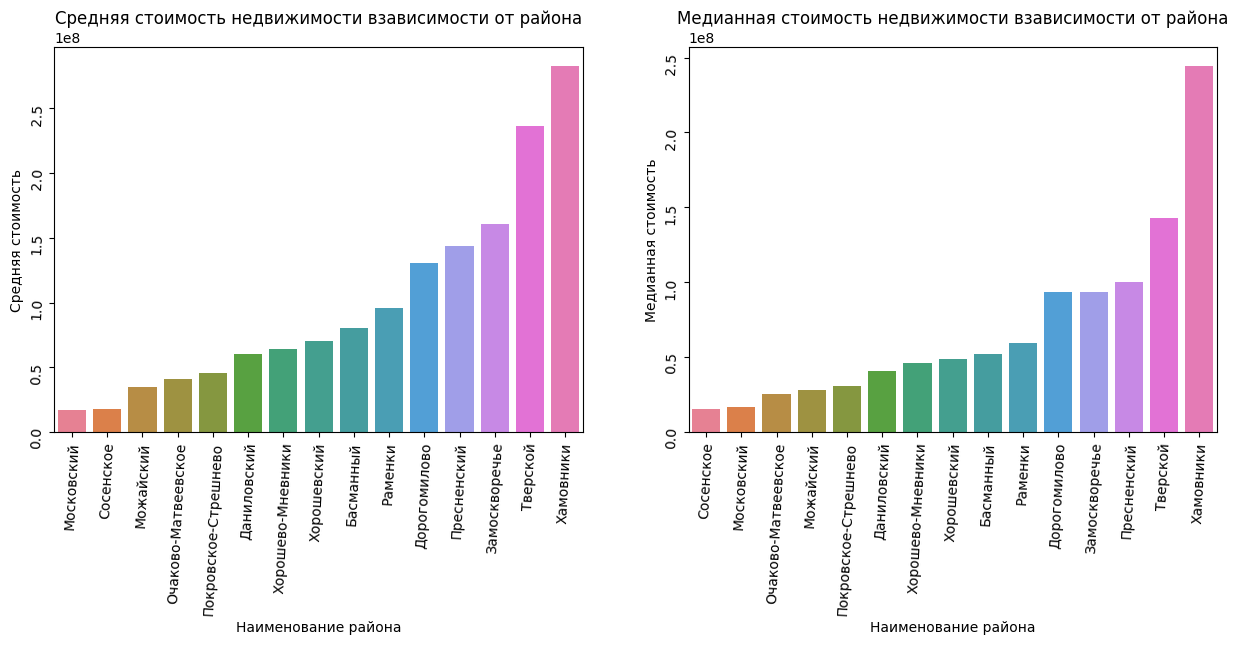

In [29]:
picture_district_price(data)

* однозначно есть зависимость от района, Хамовники - богатый район, следовательно цены выше.

district,Покровское-Стрешнево,Аэропорт,Щукино,Сокольники,Тропарево-Никулино,Ростокино,Филевский парк,Ломоносовский,Даниловский,Проспект Вернадского,...,Красносельский,Таганский,Дорогомилово,Пресненский,Замоскворечье,Мещанский,Тверской,Арбат,Хамовники,Якиманка
price_rub,"45,587,920","46,265,836","48,025,381","48,244,933","48,722,847","49,539,295","52,402,330","56,926,292","60,760,240","62,318,812",...,"108,861,888","111,985,338","130,542,626","143,373,871","160,657,875","186,532,608","236,214,094","237,113,848","283,030,626","316,659,643"


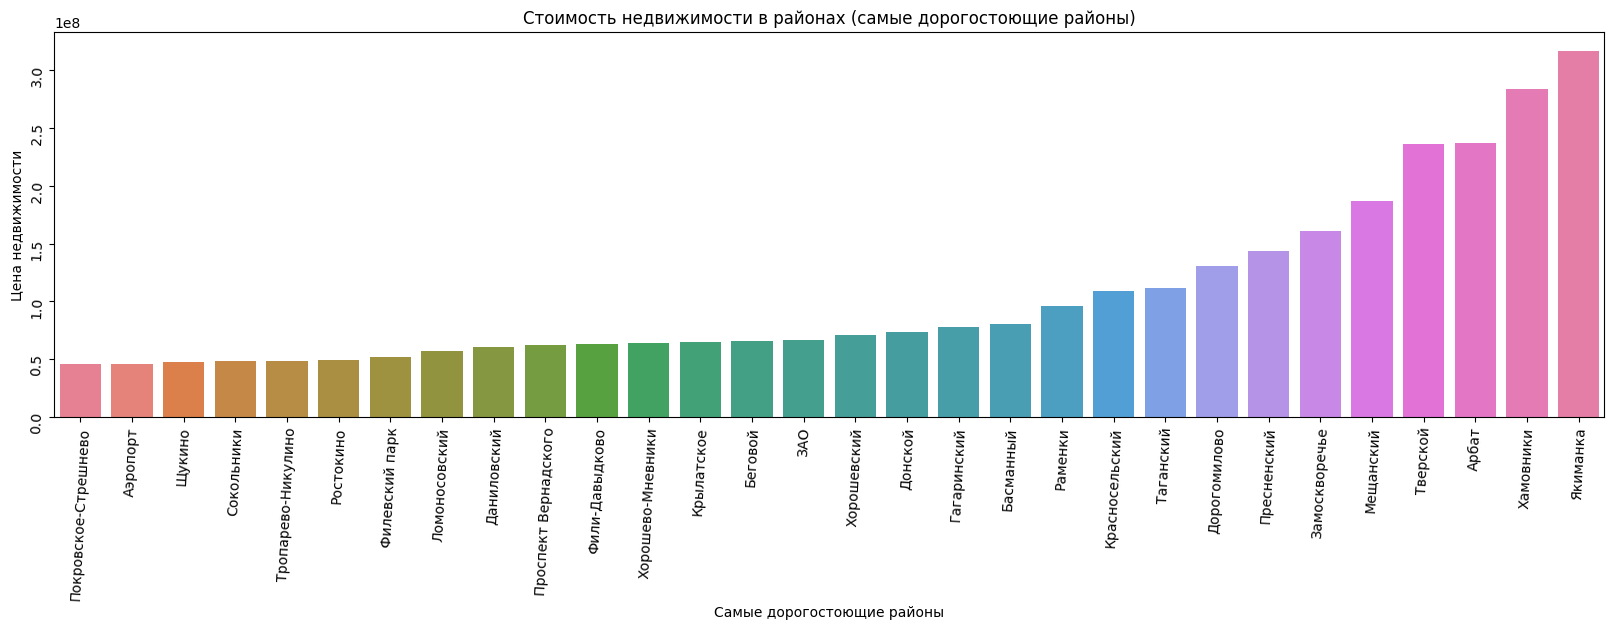

In [30]:
picture_district_price_ascending(data)

* стоит отметить, что самые дорогостоющие районы находятся внутри МКАДа, и стянуты к центру Москвы. Но брать этот анализ как основной - нельзя. Предполагаю, что в самых дорогих районах присутствует недвижимость с заоблачной ценой, которая ломает среднюю цену.

<h2>2.5 Зависимость цены от типа транспорта до метро</h2>

In [31]:
metro_transport_value_c(data)

,count
metro_transport,
walk,20305
transport,5555


* для честного обзора цен, мы возьмем 5555 типа walk, в одинаковом ценовом диапозоне, как и у transport

,mean,median
metro_transport,,
transport,"40,669,529","18,416,450"
walk,"72,820,995","32,574,360"


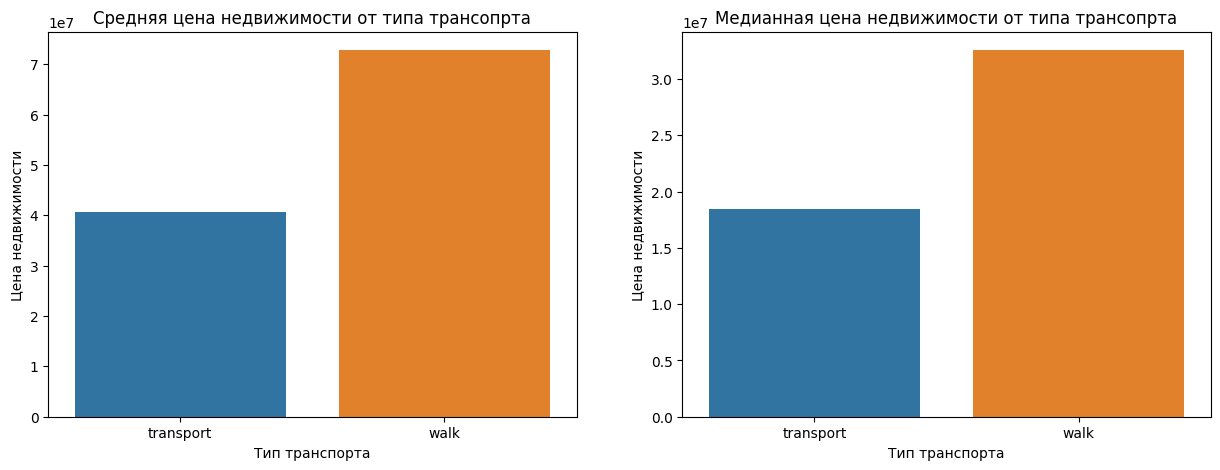

In [32]:
walk_transport_metro_different_price(data)

* опасно делать какие-то выводы. В данном случае возможно влияние аномальных значений. Для закрепления эксперимента мы возьмем диапозон цена недвижимости от 20,000,000 рублей до 60,000,000 рублей, по 1000 объектов с каждой стороны.

,mean,median
metro_transport,,
transport,"31,094,555","28,033,297"
walk,"34,513,995","31,212,770"


,mean,median
metro_transport,,
transport,"16,994,087","15,900,000"
walk,"19,856,707","19,765,628"


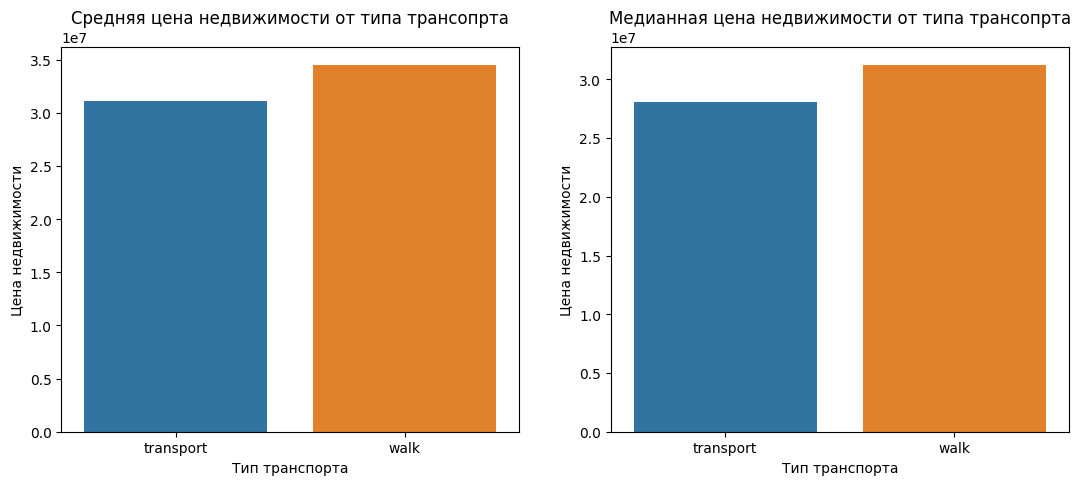

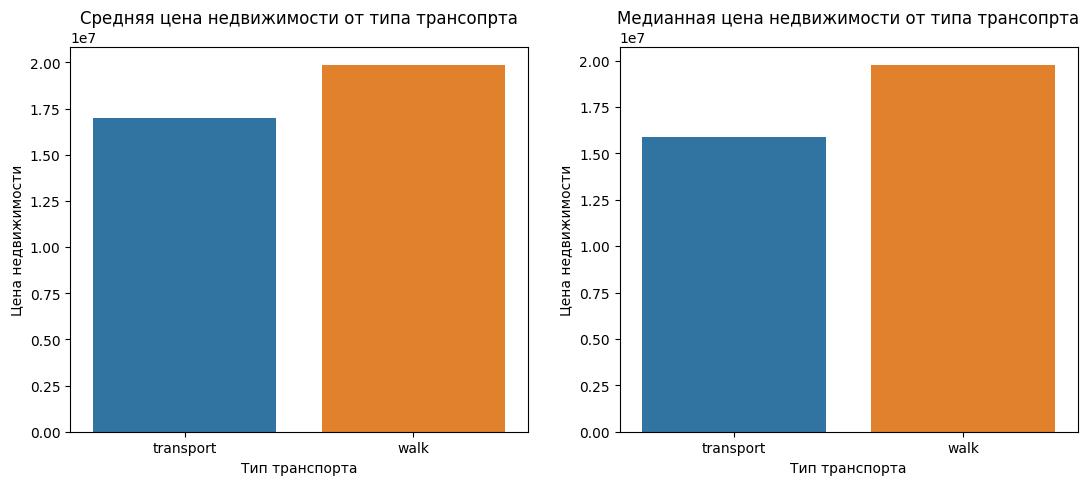

In [33]:
walk_transport_between_thousand(data)
walk_transport_between_thousand(data, min_price=10000000, max_price=30000000, n=500, random_state=20)

* в дополнение проведем статистический тест.

## Тест Шапиро-Уилка на нормальность

**Уровень значимости:** α = 0.05

**Гипотезы:**
- **H₀:** данные распределены нормально
- **H₁:** данные **НЕ** распределены нормально

**Критерий принятия решения:**
- Если p-value < α → отвергаем H₀ (распределение не нормальное)
- Если p-value ≥ α → не отвергаем H₀ (распределение нормальное)

In [34]:
print('Тест №1')
test_of_normal(data)
print('Тест №2')
test_of_normal(data, min_price=10000000, max_price=30000000, n=500, random_state=20)

Тест №1
p-value = 0.000
❌ Распределение не нормальное
p-value = 0.000
❌ Распределение не нормальное
Тест №2
p-value = 0.000
❌ Распределение не нормальное
p-value = 0.000
❌ Распределение не нормальное


* будем использовать U-критерий Манна-Уитни

In [35]:
print('Тест №1')
test_mannwhitney(data)
print('Тест №2')
test_mannwhitney(data, min_price=10000000, max_price=30000000, n=500, random_state=20)

Тест №1
p-value - f0.000
✅ Разница статистически значима - walk дороже
Тест №2
p-value - f0.000
✅ Разница статистически значима - walk дороже


* признак является значимым для целевой переменной. Однозначно будем его использовать в модели.

<h2>2.6 Зависимость цены от типа продажи</h2>

In [65]:
value_count_seller_type(data)

seller_type,agency,specialist,owner,managementCompany,rentDepartment
count,12409,12176,1236,31,8


•	agency — риелторское агентство, продаёт от имени клиента за комиссию.  
•	specialist — частный риелтор, работает самостоятельно без агентства.  
•	owner — собственник, продаёт напрямую без посредников.  
•	managementCompany — застройщик или управляющая компания, продаёт новостройки.  
•	rentDepartment — отдел аренды/продаж, обычно у крупных девелоперов.  

In [73]:
picture_seller_type_price(data)

,mean,median
seller_type,,
agency,3.505248e+07,31900000.0
managementCompany,3.747091e+07,41000000.0
owner,3.303652e+07,30000000.0
rentDepartment,4.236711e+07,41621330.0
specialist,3.375118e+07,30500000.0


* данный признак не представляет статистческой значимости для целевой переменной. mana gementCompany и rentDepartment - самые дорогие типы, но их количество крайне мало, a медианы близки по значению, а среднее может улететь вверх только из-за одного аномального значения. Данный признак можно удалить, он представляет собой лишь шум.

<h2>3.0 Изучение целевой переменной - price_rub</h2>

* так как данные были взяты напрямую с сайта CIAN - вероятность выбросов крайне мала. Но стоит посмотреть на данные.

,count,mean,std,min,25%,50%,75%,max
price_rub,25860.0,6.676018e+07,1.105735e+08,650000.0,17300000.0,28630162.5,60359991.75,999000000.0


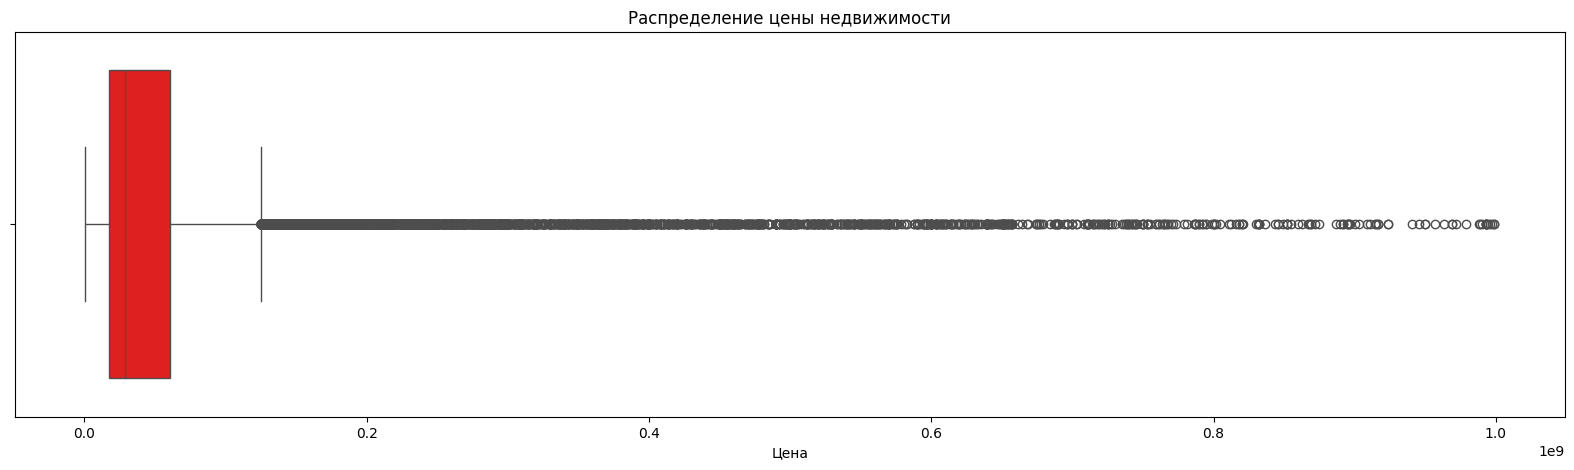

In [62]:
distribution_price(data)

* ситуация спорная. Можно сказать, что выбросы есть. Но в Москве действительно присутствует очень дорогая недвижимость (25% данных расположено выше отметки в 600 млн рублей). И нам также стоит брать ее в расчет, поэтому будет строить модели независимо от выбросов.